In [6]:
import pandas as pd
import  numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install scikit-learn

In [7]:
df=pd.read_csv("csv/traffic_data-adwords.Positions-us.csv",encoding='latin-1')
df

,ï»¿traffic_data-adwords.Positions-us-20250126-2025-01-27T11_22_24Z,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,Title,Keyword,Position,Previous position,Search Volume,CPC,Traffic,Traffic (%),Traffic Cost,Traffic Cost (%),Competition,Number of Results,Last Seen,Keyword Difficulty
1,PMPÂ® Exam & Certification | Flat 40% Off - En...,pmp certification,1,1,90500,3.76,4253,22.77,15991,24.66,0.6,166000000,2024-12-31,78
2,PMPÂ® Exam & Certification | Confidently Ace T...,pmp certification,1,1,90500,3.76,4253,22.77,15991,24.66,0.6,172000000,2025-01-01,78
3,PMPÂ® Training & Exam | Special Offer: Get $40...,pmp certification,1,2,90500,3.82,1176,6.29,4492,6.92,0.65,154000000,2025-01-14,77
4,CSM Scrum Master Course Online | Today's Offer...,scrum master certification,1,1,18100,3.21,850,4.55,2728,4.2,0.64,32000000,2025-01-10,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,PMPÂ® Exam & Certification - Flat 40% Off - En...,pmp certification 35 hours online training,4,4,40,7.75,0,0,0,0,0.61,28500000,2024-12-31,31
196,Certified Scrum Product OwnerÂ® | Limited Offe...,scrum alliance csm certification cost,4,4,90,2.62,0,0,0,0,0.39,512000,2025-01-16,47
197,PMPÂ® Certification Course,duration of pmp course,2,2,50,2.61,0,0,0,0,0.24,21900000,2025-01-22,46
198,TOGAFÂ® Certification Exam Cost | TOGAFÂ® Free...,togaf certification price,4,4,30,1.94,0,0,0,0,0.3,384000,2025-01-13,24


In [12]:
df.columns=df.iloc[0]
df=df[1:]
df.reset_index(drop=True,inplace=True)
df = df.dropna(axis=1, how='all')
df

,Title,Keyword,Position,Previous position,Search Volume,CPC,Traffic,Traffic (%),Traffic Cost,Traffic Cost (%),Competition,Number of Results,Last Seen,Keyword Difficulty
0,PMPÂ® Exam & Certification | Flat 40% Off - En...,pmp certification,1,1,90500,3.76,4253,22.77,15991,24.66,0.6,166000000,2024-12-31,78
1,PMPÂ® Exam & Certification | Confidently Ace T...,pmp certification,1,1,90500,3.76,4253,22.77,15991,24.66,0.6,172000000,2025-01-01,78
2,PMPÂ® Training & Exam | Special Offer: Get $40...,pmp certification,1,2,90500,3.82,1176,6.29,4492,6.92,0.65,154000000,2025-01-14,77
3,CSM Scrum Master Course Online | Today's Offer...,scrum master certification,1,1,18100,3.21,850,4.55,2728,4.2,0.64,32000000,2025-01-10,70
4,PMPÂ® Certification | Ace PMP Exam in 1st Attempt,pmp certification,3,3,90500,3.82,814,4.35,3109,4.79,0.65,165000000,2025-01-07,78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,PMPÂ® Exam & Certification - Flat 40% Off - En...,pmp certification 35 hours online training,4,4,40,7.75,0,0,0,0,0.61,28500000,2024-12-31,31
194,Certified Scrum Product OwnerÂ® | Limited Offe...,scrum alliance csm certification cost,4,4,90,2.62,0,0,0,0,0.39,512000,2025-01-16,47
195,PMPÂ® Certification Course,duration of pmp course,2,2,50,2.61,0,0,0,0,0.24,21900000,2025-01-22,46
196,TOGAFÂ® Certification Exam Cost | TOGAFÂ® Free...,togaf certification price,4,4,30,1.94,0,0,0,0,0.3,384000,2025-01-13,24


In [51]:
df.columns

Index([             'Title',            'KeyWord',           'Position',
        'Previous position',      'Search Volume',                'CPC',
                  'Traffic',        'Traffic (%)',       'Traffic Cost',
         'Traffic Cost (%)',        'Competition',  'Number of Results',
                'Last Seen', 'Keyword Difficulty',                  nan],
      dtype='object', name=0)

In [52]:
df=df.iloc[:,:-1]
df

,Title,KeyWord,Position,Previous position,Search Volume,CPC,Traffic,Traffic (%),Traffic Cost,Traffic Cost (%),Competition,Number of Results,Last Seen,Keyword Difficulty
0,PMP® Exam & Certification | Flat 40% Off - Enr...,pmp certification,1,1,90500,3.76,4253,22.77,15991,24.66,0.6,166000000,2024-12-31,78
1,PMP® Exam & Certification | Confidently Ace Th...,pmp certification,1,1,90500,3.76,4253,22.77,15991,24.66,0.6,172000000,2025-01-01,78
2,PMP® Training & Exam | Special Offer: Get $400...,pmp certification,1,2,90500,3.82,1176,6.29,4492,6.92,0.65,154000000,2025-01-14,77
3,CSM Scrum Master Course Online | Today's Offer...,scrum master certification,1,1,18100,3.21,850,4.55,2728,4.2,0.64,32000000,2025-01-10,70
4,PMP® Certification | Ace PMP Exam in 1st Attempt,pmp certification,3,3,90500,3.82,814,4.35,3109,4.79,0.65,165000000,2025-01-07,78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,PMP® Exam & Certification - Flat 40% Off - Enr...,pmp certification,4,4,40,7.75,0,0,0,0,0.61,28500000,2024-12-31,31
195,Certified Scrum Product Owner® | Limited Offer...,scrum master certification,4,4,90,2.62,0,0,0,0,0.39,512000,2025-01-16,47
196,PMP® Certification Course,pmp certification,2,2,50,2.61,0,0,0,0,0.24,21900000,2025-01-22,46
197,TOGAF® Certification Exam Cost | TOGAF® Free E...,togaf certification,4,4,30,1.94,0,0,0,0,0.3,384000,2025-01-13,24


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Title               199 non-null    object
 1   KeyWord             199 non-null    object
 2   Position            199 non-null    object
 3   Previous position   199 non-null    object
 4   Search Volume       199 non-null    object
 5   CPC                 199 non-null    object
 6   Traffic             199 non-null    object
 7   Traffic (%)         199 non-null    object
 8   Traffic Cost        199 non-null    object
 9   Traffic Cost (%)    199 non-null    object
 10  Competition         199 non-null    object
 11  Number of Results   199 non-null    object
 12  Last Seen           199 non-null    object
 13  Keyword Difficulty  198 non-null    object
dtypes: object(14)
memory usage: 21.9+ KB


In [13]:
df.isnull().sum()

0
Title                 0
Keyword               0
Position              0
Previous position     0
Search Volume         0
CPC                   0
Traffic               0
Traffic (%)           0
Traffic Cost          0
Traffic Cost (%)      0
Competition           0
Number of Results     0
Last Seen             0
Keyword Difficulty    0
dtype: int64

In [14]:
df.dropna(inplace=True)

In [15]:
df

,Title,Keyword,Position,Previous position,Search Volume,CPC,Traffic,Traffic (%),Traffic Cost,Traffic Cost (%),Competition,Number of Results,Last Seen,Keyword Difficulty
0,PMPÂ® Exam & Certification | Flat 40% Off - En...,pmp certification,1,1,90500,3.76,4253,22.77,15991,24.66,0.6,166000000,2024-12-31,78
1,PMPÂ® Exam & Certification | Confidently Ace T...,pmp certification,1,1,90500,3.76,4253,22.77,15991,24.66,0.6,172000000,2025-01-01,78
2,PMPÂ® Training & Exam | Special Offer: Get $40...,pmp certification,1,2,90500,3.82,1176,6.29,4492,6.92,0.65,154000000,2025-01-14,77
3,CSM Scrum Master Course Online | Today's Offer...,scrum master certification,1,1,18100,3.21,850,4.55,2728,4.2,0.64,32000000,2025-01-10,70
4,PMPÂ® Certification | Ace PMP Exam in 1st Attempt,pmp certification,3,3,90500,3.82,814,4.35,3109,4.79,0.65,165000000,2025-01-07,78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,PMPÂ® Exam & Certification - Flat 40% Off - En...,pmp certification 35 hours online training,4,4,40,7.75,0,0,0,0,0.61,28500000,2024-12-31,31
194,Certified Scrum Product OwnerÂ® | Limited Offe...,scrum alliance csm certification cost,4,4,90,2.62,0,0,0,0,0.39,512000,2025-01-16,47
195,PMPÂ® Certification Course,duration of pmp course,2,2,50,2.61,0,0,0,0,0.24,21900000,2025-01-22,46
196,TOGAFÂ® Certification Exam Cost | TOGAFÂ® Free...,togaf certification price,4,4,30,1.94,0,0,0,0,0.3,384000,2025-01-13,24


In [16]:
df.describe(include='all')

,Title,Keyword,Position,Previous position,Search Volume,CPC,Traffic,Traffic (%),Traffic Cost,Traffic Cost (%),Competition,Number of Results,Last Seen,Keyword Difficulty
count,198,198,198,198,198,198,198,198,198,198,198,198,198,198
unique,108,159,6,7,31,105,51,44,77,46,56,167,30,62
top,CSM Scrum Master Course Online | Today's Offer...,pmp certification,1,1,70,2.31,0,0,0,0,0.14,4210000,2024-12-31,44
freq,11,6,70,67,19,24,50,80,59,95,24,4,23,12


In [58]:
df

,Title,KeyWord,Position,Previous position,Search Volume,CPC,Traffic,Traffic (%),Traffic Cost,Traffic Cost (%),Competition,Number of Results,Last Seen,Keyword Difficulty
0,PMP® Exam & Certification | Flat 40% Off - Enr...,pmp certification,1,1,90500,3.76,4253,22.77,15991,24.66,0.6,166000000,2024-12-31,78
1,PMP® Exam & Certification | Confidently Ace Th...,pmp certification,1,1,90500,3.76,4253,22.77,15991,24.66,0.6,172000000,2025-01-01,78
2,PMP® Training & Exam | Special Offer: Get $400...,pmp certification,1,2,90500,3.82,1176,6.29,4492,6.92,0.65,154000000,2025-01-14,77
3,CSM Scrum Master Course Online | Today's Offer...,scrum master certification,1,1,18100,3.21,850,4.55,2728,4.2,0.64,32000000,2025-01-10,70
4,PMP® Certification | Ace PMP Exam in 1st Attempt,pmp certification,3,3,90500,3.82,814,4.35,3109,4.79,0.65,165000000,2025-01-07,78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,PMP® Exam & Certification - Flat 40% Off - Enr...,pmp certification,4,4,40,7.75,0,0,0,0,0.61,28500000,2024-12-31,31
195,Certified Scrum Product Owner® | Limited Offer...,scrum master certification,4,4,90,2.62,0,0,0,0,0.39,512000,2025-01-16,47
196,PMP® Certification Course,pmp certification,2,2,50,2.61,0,0,0,0,0.24,21900000,2025-01-22,46
197,TOGAF® Certification Exam Cost | TOGAF® Free E...,togaf certification,4,4,30,1.94,0,0,0,0,0.3,384000,2025-01-13,24


In [17]:
from re import X


numer=['Position','Previous position','Search Volume','Traffic','Traffic Cost','Number of Results','Keyword Difficulty']
flo=['CPC','Traffic (%)','Traffic Cost (%)','Competition']
for x in numer:
  if x in df.columns:
     df[x]=pd.to_numeric(df[x],errors='coerce')
for x in flo:
  if x in df.columns:
     df[x]=pd.to_numeric(df[x],errors='coerce').astype(float)







In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Title               198 non-null    object 
 1   Keyword             198 non-null    object 
 2   Position            198 non-null    int64  
 3   Previous position   198 non-null    int64  
 4   Search Volume       198 non-null    int64  
 5   CPC                 198 non-null    float64
 6   Traffic             198 non-null    int64  
 7   Traffic (%)         198 non-null    float64
 8   Traffic Cost        198 non-null    int64  
 9   Traffic Cost (%)    198 non-null    float64
 10  Competition         198 non-null    float64
 11  Number of Results   198 non-null    int64  
 12  Last Seen           198 non-null    object 
 13  Keyword Difficulty  198 non-null    int64  
dtypes: float64(4), int64(7), object(3)
memory usage: 21.8+ KB


In [19]:
df['Last Seen']=pd.to_datetime(df['Last Seen'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Title               198 non-null    object        
 1   Keyword             198 non-null    object        
 2   Position            198 non-null    int64         
 3   Previous position   198 non-null    int64         
 4   Search Volume       198 non-null    int64         
 5   CPC                 198 non-null    float64       
 6   Traffic             198 non-null    int64         
 7   Traffic (%)         198 non-null    float64       
 8   Traffic Cost        198 non-null    int64         
 9   Traffic Cost (%)    198 non-null    float64       
 10  Competition         198 non-null    float64       
 11  Number of Results   198 non-null    int64         
 12  Last Seen           198 non-null    datetime64[ns]
 13  Keyword Difficulty  198 non-null    int64         

<Axes: xlabel='0', ylabel='0'>

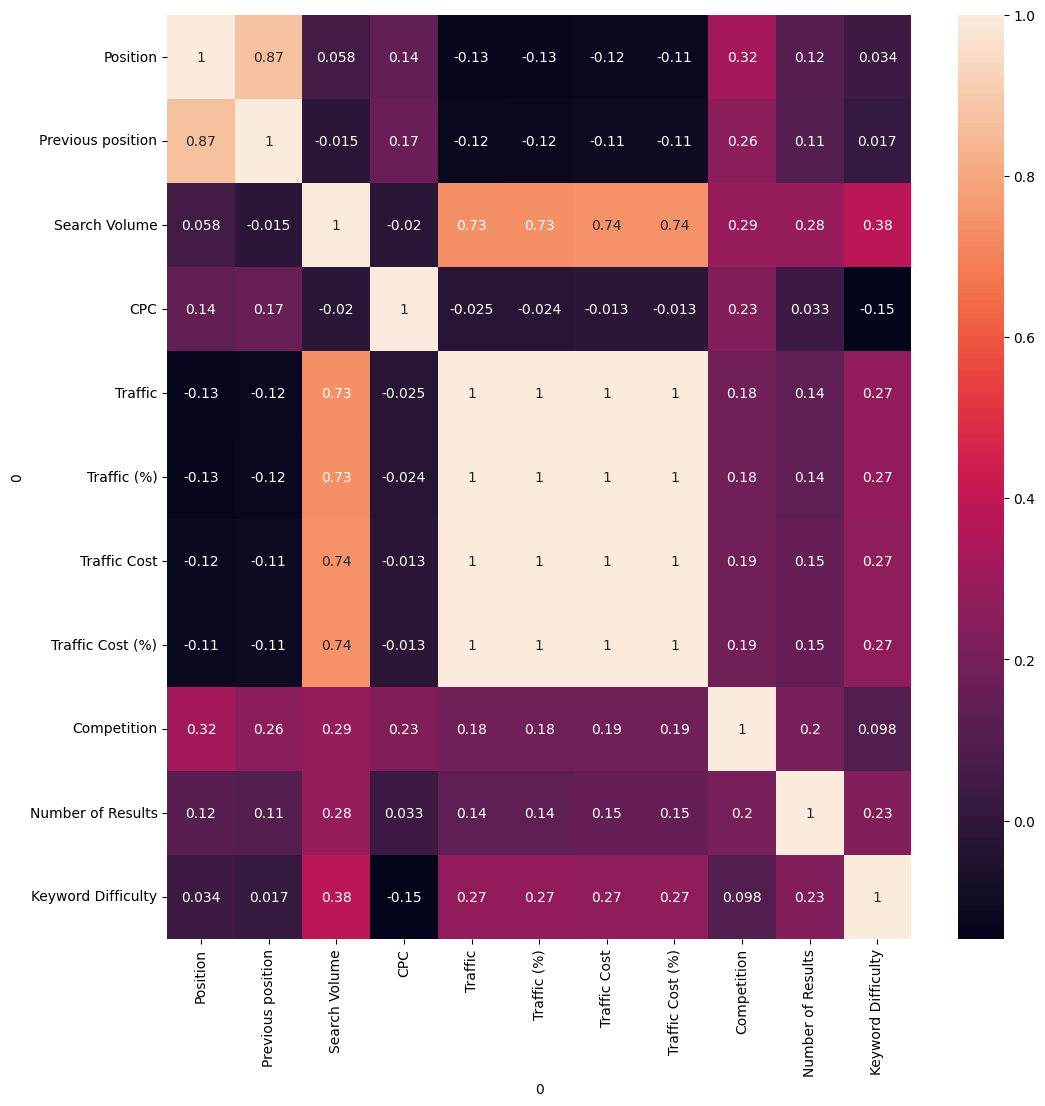

In [20]:
numeric_df=df.select_dtypes(include='number')
numeric_df.corr()
plt.figure(figsize=(12,12))
sns.heatmap(numeric_df.corr(),annot=True)

In [21]:
#position and previous position>corr is 0.87
#traffic cost and traffic cost% vs search volume  >corr is 0.74
#search volume vs keyword difficulty /competition>lower corr
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
x=['Search Volume','Competition']
y=[['Competition']]

scaler=StandardScaler()
X_scaled=scaler.fit_transform(df[x])

inertia = []
for n in range(1 , 15):
    algorithm = (KMeans(n_clusters = n ,init='k-means++', n_init = 10 ,max_iter=300,
                        tol=0.0001,  random_state= 42 , algorithm='elkan') )
    algorithm.fit(X_scaled)
    inertia.append(algorithm.inertia_)

C:\Users\Dimple\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\cluster\_kmeans.py:1414: RuntimeWarning: algorithm='elkan' doesn't make sense for a single cluster. Using 'lloyd' instead.
  warnings.warn(


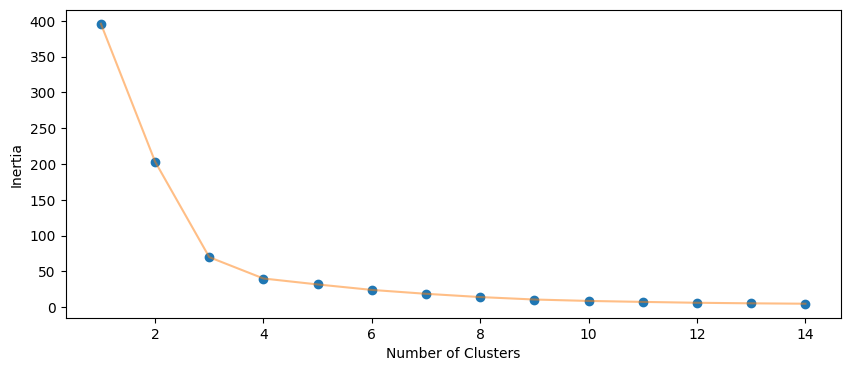

In [22]:
plt.figure(1 , figsize = (10 ,4))
plt.plot(np.arange(1 , 15) , inertia , 'o')
plt.plot(np.arange(1 , 15) , inertia , '-' , alpha = 0.5)
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()

In [23]:
algorithm = (KMeans(n_clusters = 3 ,init='k-means++', n_init = 10 ,max_iter=300,
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )
algorithm.fit(X_scaled)
labels1 = algorithm.labels_
centroids1 = algorithm.cluster_centers_

In [24]:
h = 0.02
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = algorithm.predict(np.c_[xx.ravel(), yy.ravel()])

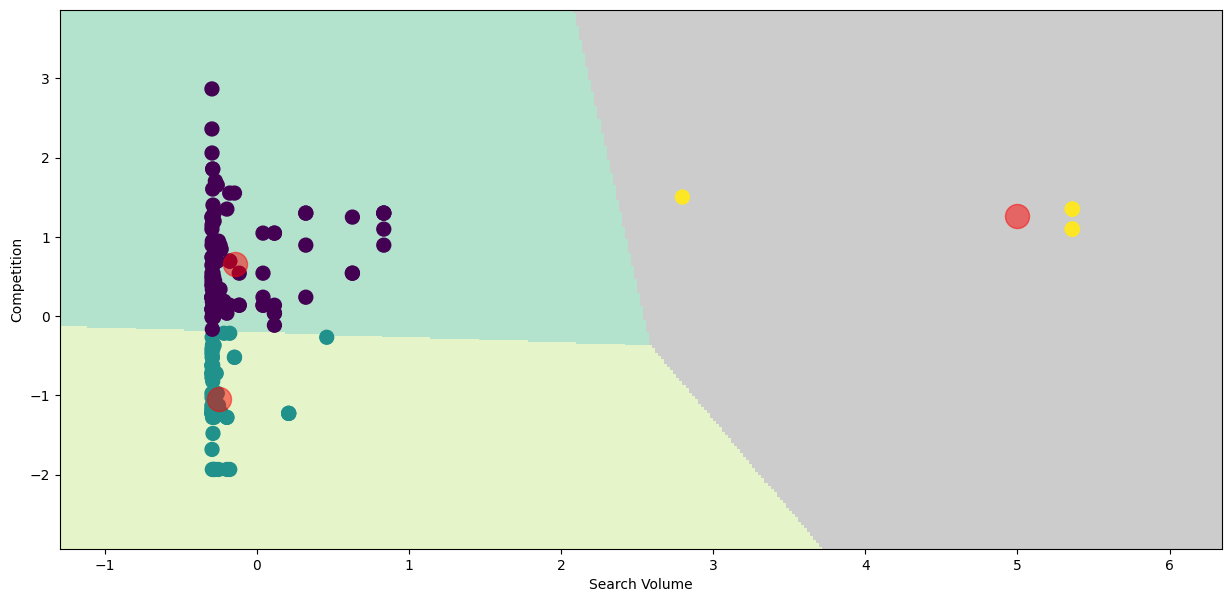

In [25]:
plt.figure(1 , figsize = (15 , 7) )
plt.clf()
Z = Z.reshape(xx.shape)
plt.imshow(Z , interpolation='nearest',
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap = plt.cm.Pastel2, aspect = 'auto', origin='lower')

plt.scatter( x = X_scaled[:, 0], y = X_scaled[:, 1], c = labels1, s = 100)
plt.scatter(x = centroids1[: , 0] , y =  centroids1[: , 1] , s = 300 , c = 'red' , alpha = 0.5)
plt.ylabel('Competition') , plt.xlabel('Search Volume')
plt.show()

C:\Users\Dimple\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but FunctionTransformer was fitted without feature names
  warnings.warn(
C:\Users\Dimple\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\cluster\_kmeans.py:1414: RuntimeWarning: algorithm='elkan' doesn't make sense for a single cluster. Using 'lloyd' instead.
  warnings.warn(


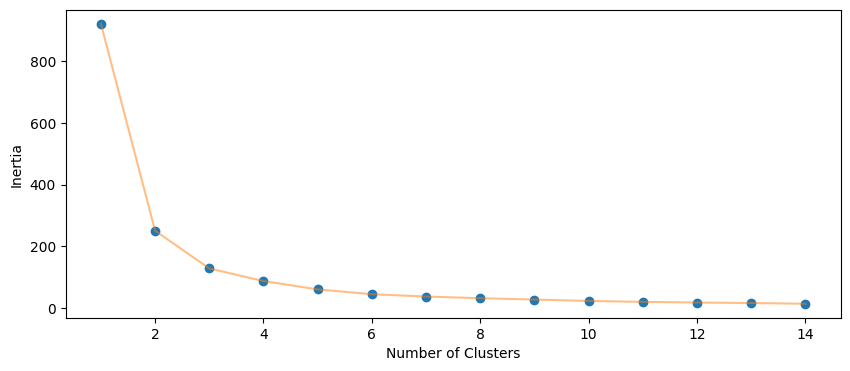

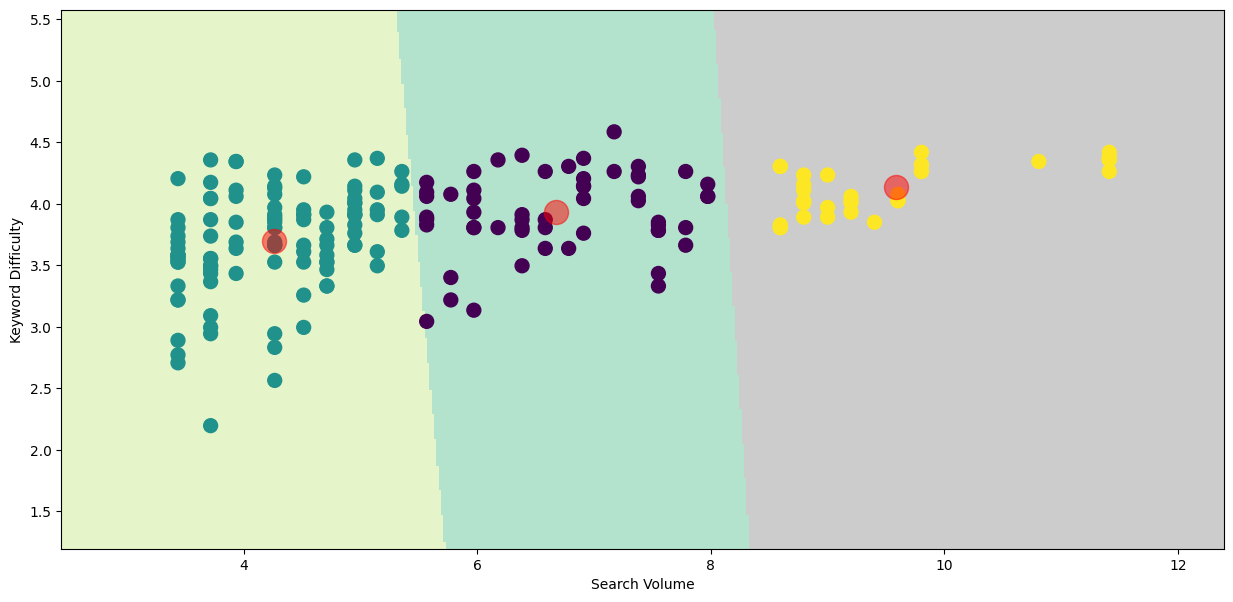

In [26]:
x=['Search Volume','Keyword Difficulty']
y=[['Keyword Difficulty']]

from sklearn.preprocessing import FunctionTransformer

transformer=FunctionTransformer(np.log1p,validate=True)
X_scaled=transformer.transform(df[x])


inertia = []
for n in range(1 , 15):
    algorithm = (KMeans(n_clusters = n ,init='k-means++', n_init = 10 ,max_iter=300,
                        tol=0.0001,  random_state= 42 , algorithm='elkan') )
    algorithm.fit(X_scaled)
    inertia.append(algorithm.inertia_)
plt.figure(1 , figsize = (10 ,4))
plt.plot(np.arange(1 , 15) , inertia , 'o')
plt.plot(np.arange(1 , 15) , inertia , '-' , alpha = 0.5)
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()

algorithm = (KMeans(n_clusters = 3 ,init='k-means++', n_init = 10 ,max_iter=300,
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )
algorithm.fit(X_scaled)
labels1 = algorithm.labels_
centroids1 = algorithm.cluster_centers_

h = 0.02
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = algorithm.predict(np.c_[xx.ravel(), yy.ravel()])

plt.figure(1 , figsize = (15 , 7) )
plt.clf()
Z = Z.reshape(xx.shape)
plt.imshow(Z , interpolation='nearest',
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap = plt.cm.Pastel2, aspect = 'auto', origin='lower')

plt.scatter( x = X_scaled[:, 0], y = X_scaled[:, 1], c = labels1, s = 100)
plt.scatter(x = centroids1[: , 0] , y =  centroids1[: , 1] , s = 300 , c = 'red' , alpha = 0.5)
plt.ylabel('Keyword Difficulty') , plt.xlabel('Search Volume')
plt.show()

C:\Users\Dimple\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\cluster\_kmeans.py:1414: RuntimeWarning: algorithm='elkan' doesn't make sense for a single cluster. Using 'lloyd' instead.
  warnings.warn(
C:\Users\Dimple\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (12) found smaller than n_clusters (13). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
C:\Users\Dimple\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (12) found smaller than n_clusters (14). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


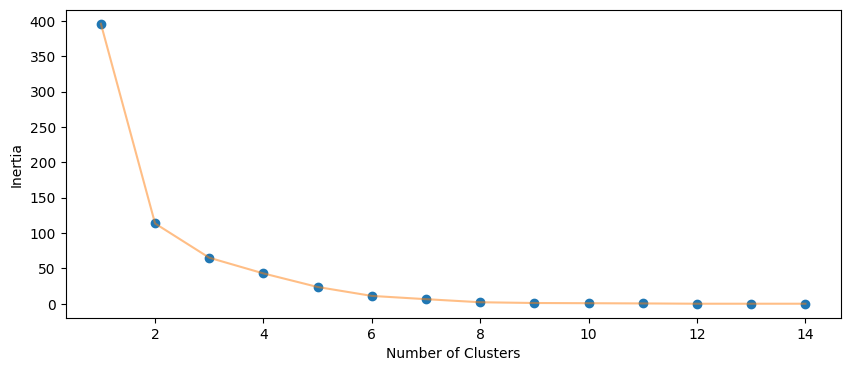

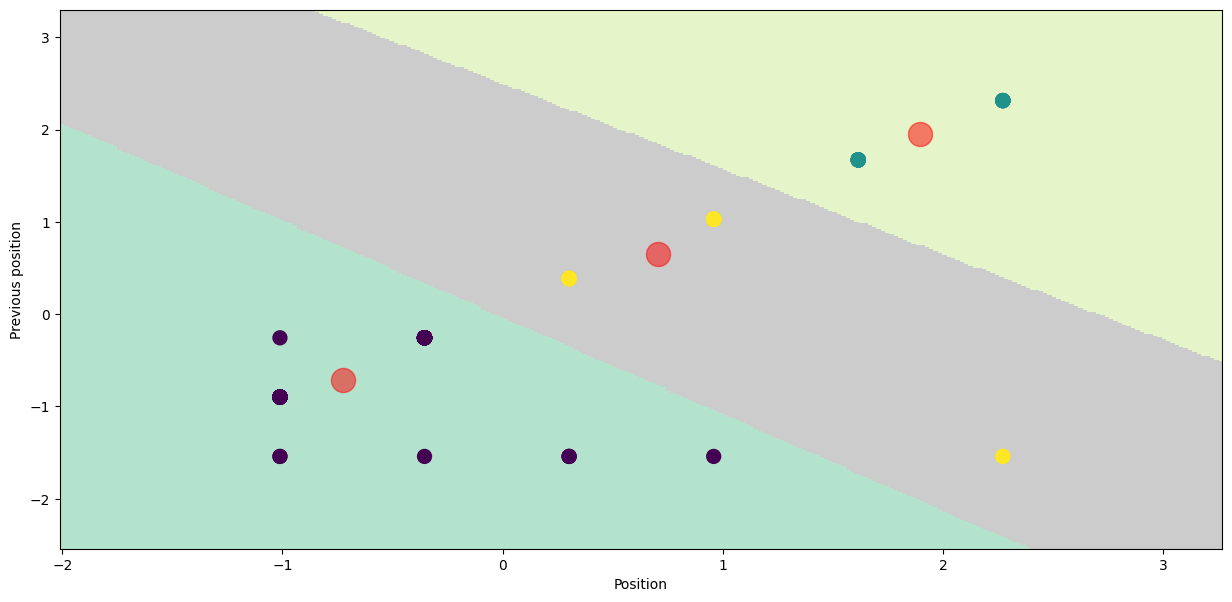

In [27]:
x=['Position','Previous position']
y=[['Previous position']]

scaler=StandardScaler()
X_scaled=scaler.fit_transform(df[x])

inertia = []
for n in range(1 , 15):
    algorithm = (KMeans(n_clusters = n ,init='k-means++', n_init = 10 ,max_iter=300,
                        tol=0.0001,  random_state= 42 , algorithm='elkan') )
    algorithm.fit(X_scaled)
    inertia.append(algorithm.inertia_)
plt.figure(1 , figsize = (10 ,4))
plt.plot(np.arange(1 , 15) , inertia , 'o')
plt.plot(np.arange(1 , 15) , inertia , '-' , alpha = 0.5)
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()

algorithm = (KMeans(n_clusters = 3 ,init='k-means++', n_init = 10 ,max_iter=300,
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )
algorithm.fit(X_scaled)
labels1 = algorithm.labels_
centroids1 = algorithm.cluster_centers_

h = 0.02
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = algorithm.predict(np.c_[xx.ravel(), yy.ravel()])

plt.figure(1 , figsize = (15 , 7) )
plt.clf()
Z = Z.reshape(xx.shape)
plt.imshow(Z , interpolation='nearest',
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap = plt.cm.Pastel2, aspect = 'auto', origin='lower')

plt.scatter( x = X_scaled[:, 0], y = X_scaled[:, 1], c = labels1, s = 100)
plt.scatter(x = centroids1[: , 0] , y =  centroids1[: , 1] , s = 300 , c = 'red' , alpha = 0.5)
plt.ylabel('Previous position') , plt.xlabel('Position')
plt.show()

C:\Users\Dimple\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but FunctionTransformer was fitted without feature names
  warnings.warn(
C:\Users\Dimple\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\cluster\_kmeans.py:1414: RuntimeWarning: algorithm='elkan' doesn't make sense for a single cluster. Using 'lloyd' instead.
  warnings.warn(


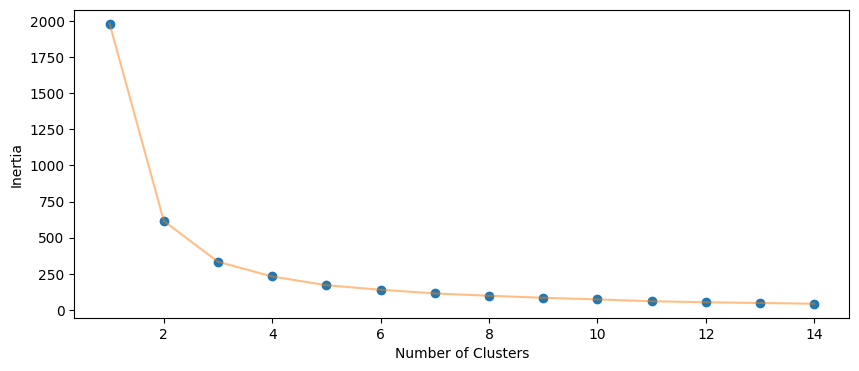

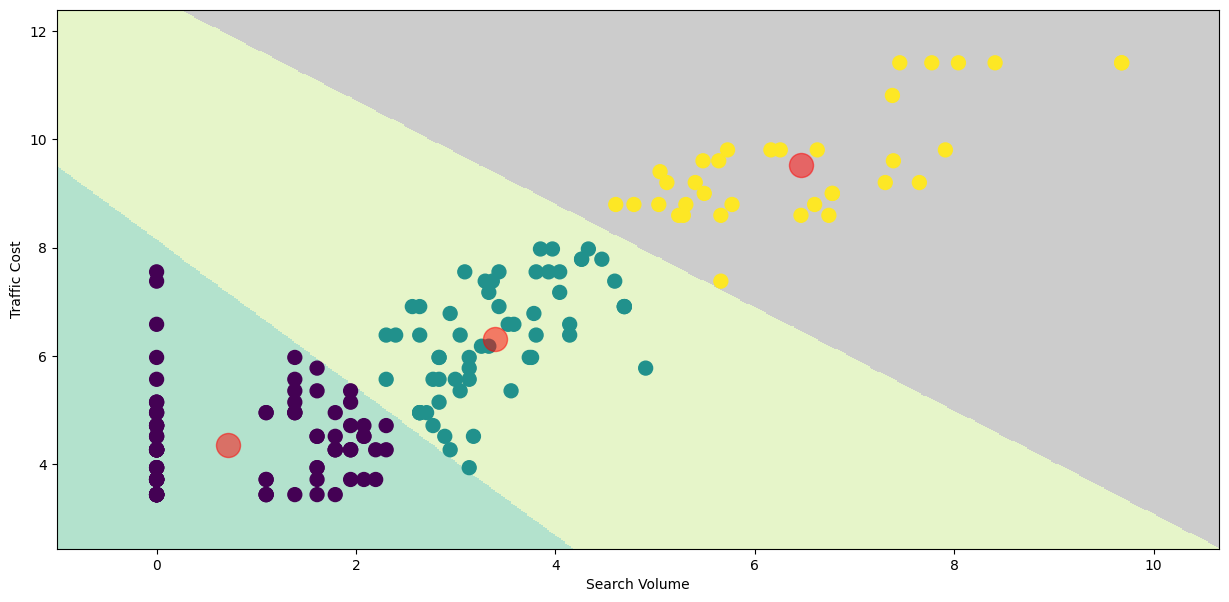

In [28]:
x=['Traffic Cost','Search Volume']
y=[['Traffic Cost']]

transformer=FunctionTransformer(np.log1p,validate=True)
X_scaled=transformer.transform(df[x])

inertia = []
for n in range(1 , 15):
    algorithm = (KMeans(n_clusters = n ,init='k-means++', n_init = 10 ,max_iter=300,
                        tol=0.0001,  random_state= 42 , algorithm='elkan') )
    algorithm.fit(X_scaled)
    inertia.append(algorithm.inertia_)
plt.figure(1 , figsize = (10 ,4))
plt.plot(np.arange(1 , 15) , inertia , 'o')
plt.plot(np.arange(1 , 15) , inertia , '-' , alpha = 0.5)
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()

algorithm = (KMeans(n_clusters = 3 ,init='k-means++', n_init = 10 ,max_iter=300,
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )
algorithm.fit(X_scaled)
labels1 = algorithm.labels_
centroids1 = algorithm.cluster_centers_

h = 0.02
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = algorithm.predict(np.c_[xx.ravel(), yy.ravel()])

plt.figure(1 , figsize = (15 , 7) )
plt.clf()
Z = Z.reshape(xx.shape)
plt.imshow(Z , interpolation='nearest',
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap = plt.cm.Pastel2, aspect = 'auto', origin='lower')

plt.scatter( x = X_scaled[:, 0], y = X_scaled[:, 1], c = labels1, s = 100)
plt.scatter(x = centroids1[: , 0] , y =  centroids1[: , 1] , s = 300 , c = 'red' , alpha = 0.5)
plt.ylabel('Traffic Cost') , plt.xlabel('Search Volume')
plt.show()